# GEOS-FP through NCCS OPeNDAP

GEOS-FP is NASA GMAO's near-real-time counterpart to MERRA-2. This example downloads a small remote subset and caches it as NetCDF.

# Imports

In [15]:
import atmPy.data_archives.nasa.geos_fp as atmgfp

# Example

## assim

This host's IPv6 route to NCCS stalls during TLS negotiation. `force_ipv4=True` uses an ephemeral loopback proxy for this connection only; the upstream NASA certificate is still verified. It can be omitted where IPv6 works. Request explicit variables because `variables=None` transfers every variable in the collection.

In [28]:
gi = atmgfp.GeosFp(force_ipv4=True)

In [29]:
gi.collection

'tavg1_2d_slv_Nx'

In [30]:
ds = gi.download(
    "2026-08-13",
    "2026-08-13",
    variables=["to3", 'tqv'],
    bbox=(-106, 39, -104, 41),
)

/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/coding/times.py:215: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/coding/times.py:215: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


In [31]:
ds

<xarray.Dataset> Size: 5kB
Dimensions:   (datetime: 9, lat: 9, lon: 7)
Coordinates:
  * datetime  (datetime) datetime64[ns] 72B 2026-08-13T00:30:00 ... 2026-08-1...
  * lat       (lat) float64 72B 39.0 39.25 39.5 39.75 40.0 40.25 40.5 40.75 41.0
  * lon       (lon) float64 56B -105.9 -105.6 -105.3 -105.0 -104.7 -104.4 -104.1
Data variables:
    to3       (datetime, lat, lon) float32 2kB ...
    tqv       (datetime, lat, lon) float32 2kB ...
Attributes:
    title:                GEOS5 FP 2d time-averaged single level diagnostics
    Conventions:          COARDS\nGrADS
    dataType:             Grid
    history:              Thu Aug 13 11:17:39 EDT 2026 : imported by GrADS Da...
    extra_das_attribute:  This is an example of metadata added using a supple...
    geos_fp_collection:   tavg1_2d_slv_Nx
    geos_fp_stream:       assim
    geos_fp_opendap_url:  https://opendap.nccs.nasa.gov/dods/GEOS-5/fp/0.25_d...

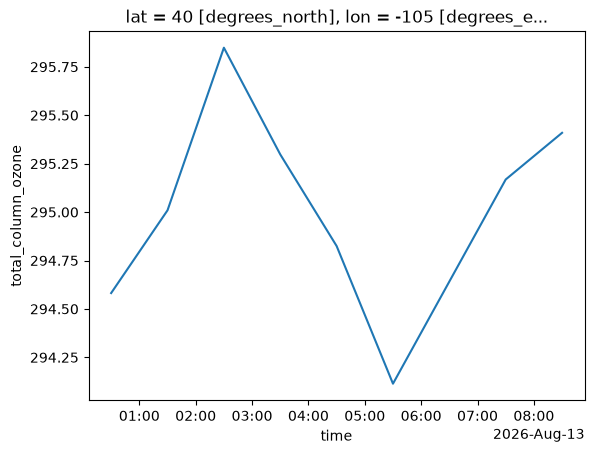

In [18]:
ds.to3.interp(lat = 40, lon = -105).plot()

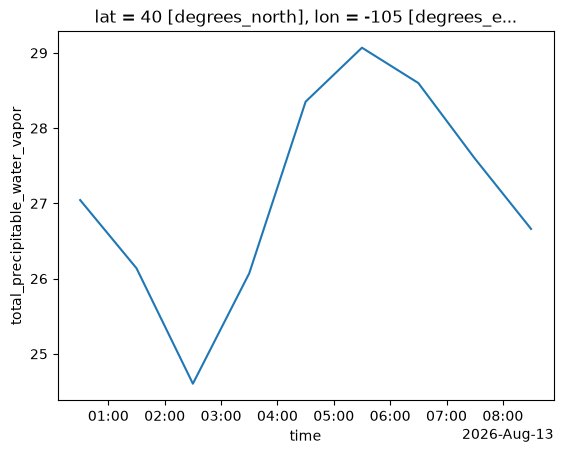

In [32]:
ds.tqv.interp(lat = 40, lon = -105).plot()

## fcast

This host's IPv6 route to NCCS stalls during TLS negotiation. `force_ipv4=True` uses an ephemeral loopback proxy for this connection only; the upstream NASA certificate is still verified. It can be omitted where IPv6 works. Request explicit variables because `variables=None` transfers every variable in the collection.

In [19]:
gi = atmgfp.GeosFp(stream='fcast', force_ipv4=True)

In [20]:
dsfc = gi.download(
    "2026-08-13",
    "2026-08-13",
    variables=["to3"],
    bbox=(-106, 39, -104, 41),
)

/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/coding/times.py:215: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/coding/times.py:215: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


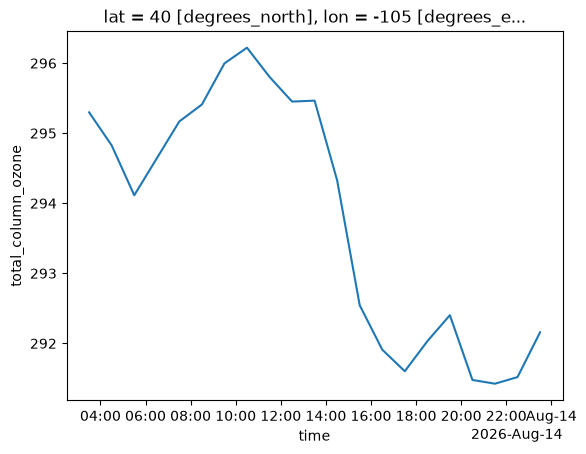

In [21]:
dsfc.to3.interp(lat = 40, lon = -105).plot()

## seamless

This host's IPv6 route to NCCS stalls during TLS negotiation. `force_ipv4=True` uses an ephemeral loopback proxy for this connection only; the upstream NASA certificate is still verified. It can be omitted where IPv6 works. Request explicit variables because `variables=None` transfers every variable in the collection.

In [23]:
gi = atmgfp.GeosFp(stream='seamless', force_ipv4=True)

In [24]:
dssl = gi.download(
    "2026-08-13",
    "2026-08-13",
    variables=["to3"],
    bbox=(-106, 39, -104, 41),
)

/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/coding/times.py:215: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/coding/times.py:215: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


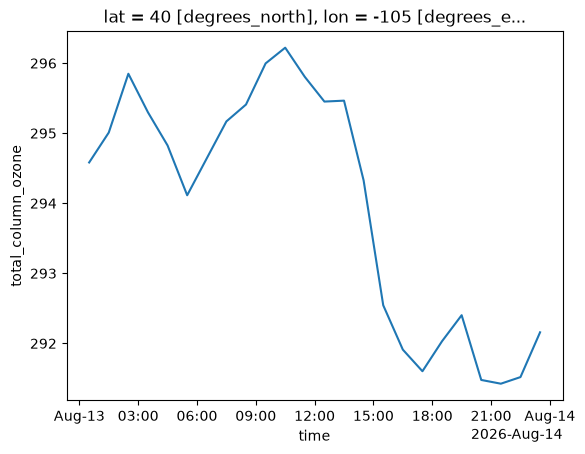

In [25]:
dssl.to3.interp(lat = 40, lon = -105).plot()

In [26]:
dssl

<xarray.Dataset> Size: 6kB
Dimensions:   (datetime: 24, lat: 9, lon: 7)
Coordinates:
  * datetime  (datetime) datetime64[ns] 192B 2026-08-13T00:30:00 ... 2026-08-...
  * lat       (lat) float64 72B 39.0 39.25 39.5 39.75 40.0 40.25 40.5 40.75 41.0
  * lon       (lon) float64 56B -105.9 -105.6 -105.3 -105.0 -104.7 -104.4 -104.1
Data variables:
    to3       (datetime, lat, lon) float32 6kB ...
Attributes:
    title:                GEOS5 FP 2d time-averaged single level diagnostics
    Conventions:          COARDS\nGrADS
    dataType:             Grid
    history:              Thu Aug 13 11:00:51 EDT 2026 : imported by GrADS Da...
    extra_das_attribute:  This is an example of metadata added using a supple...
    geos_fp_collection:   tavg1_2d_slv_Nx
    geos_fp_stream:       seamless
    geos_fp_opendap_url:  https://opendap.nccs.nasa.gov/dods/GEOS-5/fp/0.25_d...